# Rotten Tomatoes Review Prediction - Baseline

このノートブックでは、シンプルなベースラインモデルを作成します。

## 目次
1. データ読み込み
2. 簡易EDA
3. 特徴量エンジニアリング
4. モデル学習（5-Fold CV）
5. 予測ファイル作成

**環境:** このノートブックは Kaggle 互換の `.venv` を使用します。  
右上の「カーネルを選択」→ **Python 3 (ds_dojo4 .venv)** または **.venv** の Python を選んでから実行してください。

In [1]:
# ライブラリのインポート
import pandas as pd
import random
import os
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")

print("Setup complete!")

Setup complete!


In [2]:
# 再現性が得られるようシードを固定
def seed_everything(seed=40):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)


seed_everything(42)

## 1. データ読み込み

まずはデータを読み込んで、どんなデータか確認しましょう。

In [3]:
# データ読み込み（ローカル: プロジェクト直下の data/ フォルダを参照）
DATA_DIR = "data"
train = pd.read_csv(f"{DATA_DIR}/train.csv")
test = pd.read_csv(f"{DATA_DIR}/test.csv")

print(f"Train: {len(train):,} rows")
print(f"Test: {len(test):,} rows")

Train: 653,507 rows
Test: 40,716 rows


In [4]:
train.shape

(653507, 17)

In [5]:
test.shape

(40716, 16)

In [6]:
train["critic_name"].value_counts()

critic_name
Emanuel Levy           8170
Roger Ebert            6330
Dennis Schwartz        5531
Frank Swietek          5145
Jeffrey M. Anderson    4991
                       ... 
Jason Caro               10
Sky Hirschkron           10
Joey Nolfi               10
Elizabeth Kerr           10
Megan Rosenfeld          10
Name: count, Length: 1573, dtype: int64

In [7]:
test["critic_name"].value_counts()

critic_name
Matt Brunson       688
Leigh Paatsch      681
Brent McKnight     548
Abbie Bernstein    539
David Nusair       514
                  ... 
Oz                   1
Daniel Saney         1
Justin Strout        1
Derek Elley          1
Scott Wold           1
Name: count, Length: 1483, dtype: int64

In [8]:
# Trainデータの先頭5行を確認
# どんなカラムがあるか、データの形式を把握する
display(train.head())

,ID,rotten_tomatoes_link,critic_name,top_critic,publisher_name,review_date,movie_title,movie_info,content_rating,genres,directors,authors,actors,original_release_date,runtime,production_company,target
0,0,m/0814255,Andrew L. Urban,False,Urban Cinefile,2010-02-06,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,119.0,20th Century Fox,1
1,1,m/0814255,Louise Keller,False,Urban Cinefile,2010-02-06,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,119.0,20th Century Fox,1
2,2,m/0814255,David Germain,True,Associated Press,2010-02-10,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,119.0,20th Century Fox,0
3,3,m/0814255,Nick Schager,False,Slant Magazine,2010-02-10,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,119.0,20th Century Fox,0
4,4,m/0814255,Bill Goodykoontz,True,Arizona Republic,2010-02-10,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,119.0,20th Century Fox,1


In [9]:
display(test.head())


,ID,rotten_tomatoes_link,critic_name,top_critic,publisher_name,review_date,movie_title,movie_info,content_rating,genres,directors,authors,actors,original_release_date,runtime,production_company
0,653507,m/0814255,Felicia Feaster,False,Charleston City Paper,2020-01-23,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,119.0,20th Century Fox
1,653508,m/0814255,Leigh Paatsch,False,Herald Sun (Australia),2020-06-26,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,119.0,20th Century Fox
2,653509,m/0878835,Tara Thorne,False,"The Coast (Halifax, Nova Scotia)",2018-11-17,Please Give,Kate (Catherine Keener) and her husband Alex (...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",2010-04-30,90.0,Sony Pictures Classics
3,653510,m/0878835,Brian D. Johnson,False,Maclean's Magazine,2019-07-23,Please Give,Kate (Catherine Keener) and her husband Alex (...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",2010-04-30,90.0,Sony Pictures Classics
4,653511,m/0878835,Felicia Feaster,False,Charleston City Paper,2020-01-22,Please Give,Kate (Catherine Keener) and her husband Alex (...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",2010-04-30,90.0,Sony Pictures Classics


In [10]:
# カラム一覧と欠損値の確認
# 欠損値が多いカラムは特徴量として使いにくいので注意
print("カラム別の欠損値数:")
display(train.isnull().sum())

カラム別の欠損値数:


ID                           0
rotten_tomatoes_link         0
critic_name                  0
top_critic                   0
publisher_name               0
review_date                  0
movie_title                 37
movie_info                3733
content_rating              37
genres                     103
directors                 7788
authors                  30515
actors                    5169
original_release_date     6844
runtime                   3711
production_company        2873
target                       0
dtype: int64

In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 653507 entries, 0 to 653506
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     653507 non-null  int64  
 1   rotten_tomatoes_link   653507 non-null  object 
 2   critic_name            653507 non-null  object 
 3   top_critic             653507 non-null  bool   
 4   publisher_name         653507 non-null  object 
 5   review_date            653507 non-null  object 
 6   movie_title            653470 non-null  object 
 7   movie_info             649774 non-null  object 
 8   content_rating         653470 non-null  object 
 9   genres                 653404 non-null  object 
 10  directors              645719 non-null  object 
 11  authors                622992 non-null  object 
 12  actors                 648338 non-null  object 
 13  original_release_date  646663 non-null  object 
 14  runtime                649796 non-nu

In [12]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40716 entries, 0 to 40715
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     40716 non-null  int64  
 1   rotten_tomatoes_link   40716 non-null  object 
 2   critic_name            40716 non-null  object 
 3   top_critic             40716 non-null  bool   
 4   publisher_name         40716 non-null  object 
 5   review_date            40716 non-null  object 
 6   movie_title            40702 non-null  object 
 7   movie_info             40157 non-null  object 
 8   content_rating         40702 non-null  object 
 9   genres                 40686 non-null  object 
 10  directors              40050 non-null  object 
 11  authors                38531 non-null  object 
 12  actors                 40171 non-null  object 
 13  original_release_date  38911 non-null  object 
 14  runtime                40298 non-null  float64
 15  pr

In [13]:
# カラム一覧と欠損値の確認
# 欠損値が多いカラムは特徴量として使いにくいので注意
print("カラム別の欠損値数:")
display(train.isnull().sum())

カラム別の欠損値数:


ID                           0
rotten_tomatoes_link         0
critic_name                  0
top_critic                   0
publisher_name               0
review_date                  0
movie_title                 37
movie_info                3733
content_rating              37
genres                     103
directors                 7788
authors                  30515
actors                    5169
original_release_date     6844
runtime                   3711
production_company        2873
target                       0
dtype: int64

65万件データがあるので、欠損値の量はそれほど多くなさそう

In [14]:
# targetの分布を確認
# 1=Fresh（好評）, 0=Rotten（不評）
print("Target分布:")
print(train["target"].value_counts())
print(f"\nFresh率: {train['target'].mean():.1%}")

Target分布:
target
1    404562
0    248945
Name: count, dtype: int64

Fresh率: 61.9%


高評価されている映画のほうが、低評価されている映画よりも多いことがわかる

## 2. 簡易EDA

主要な特徴量とtargetの関係を確認します。

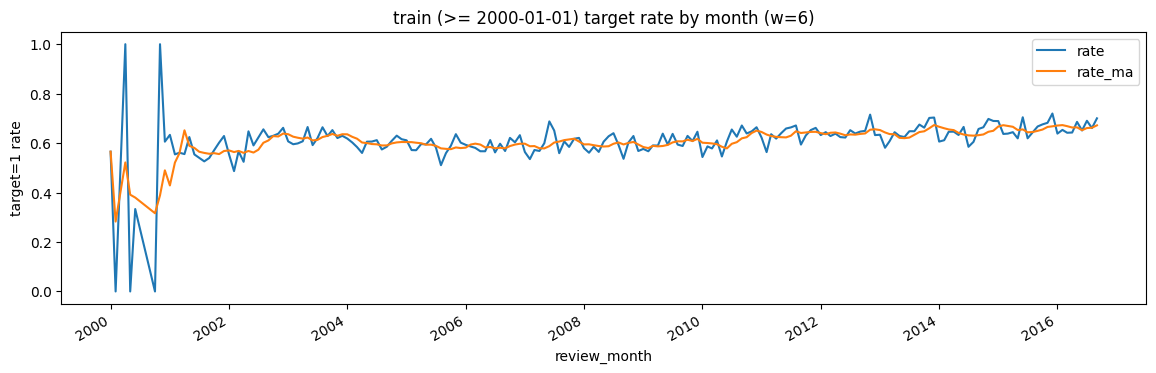

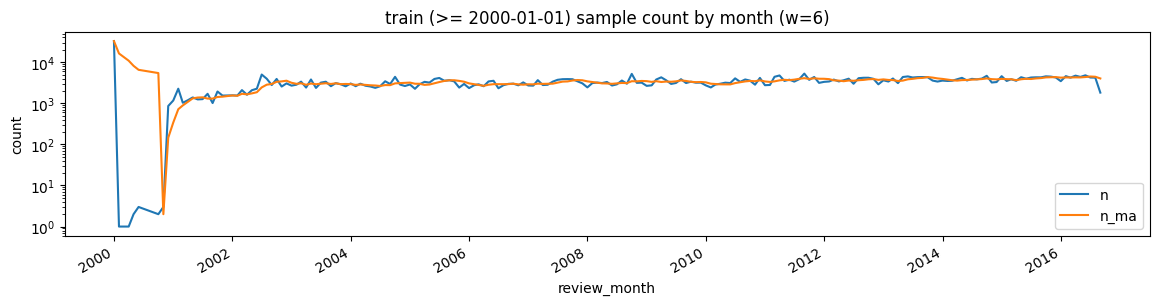

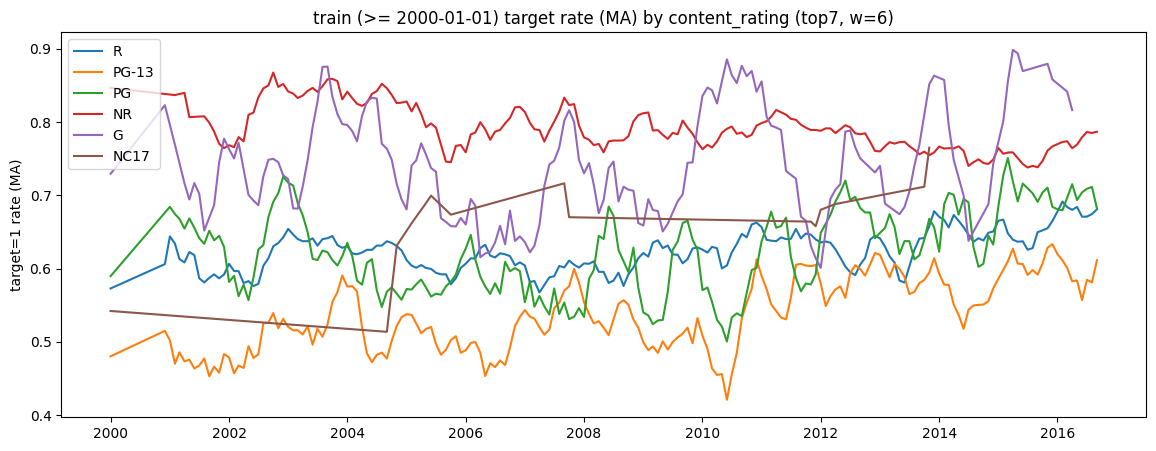

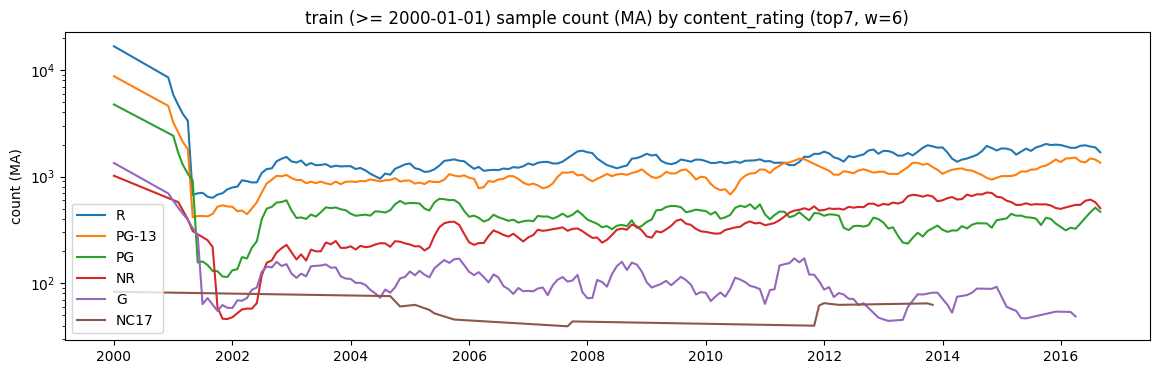

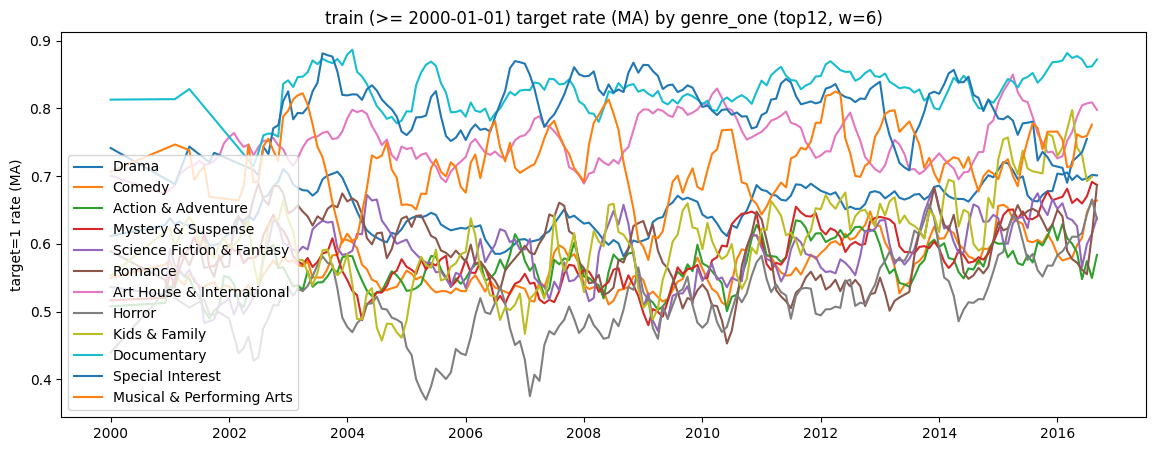

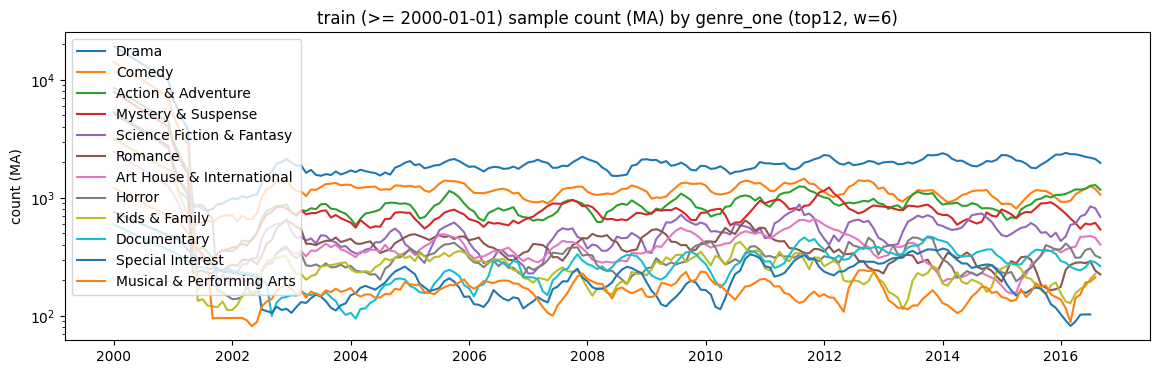

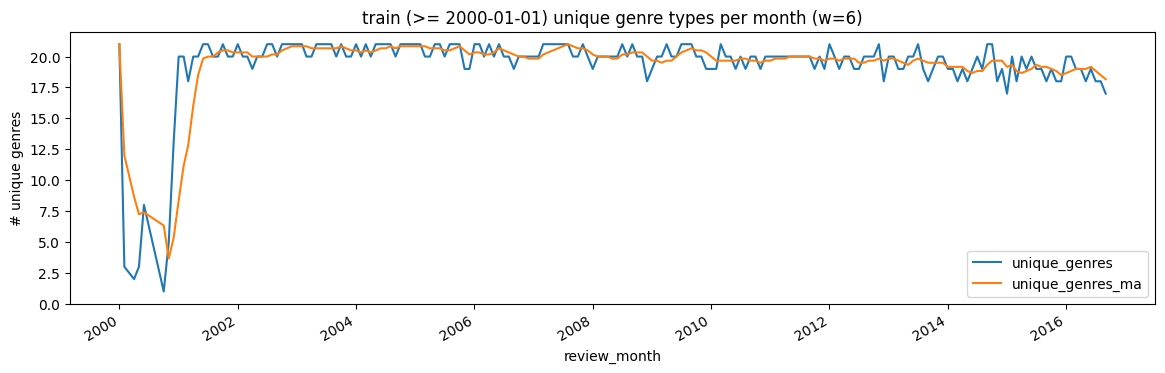

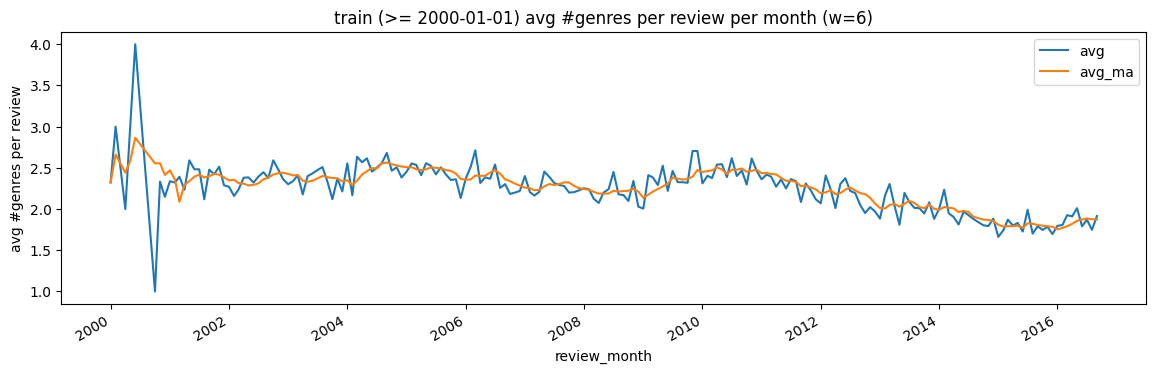

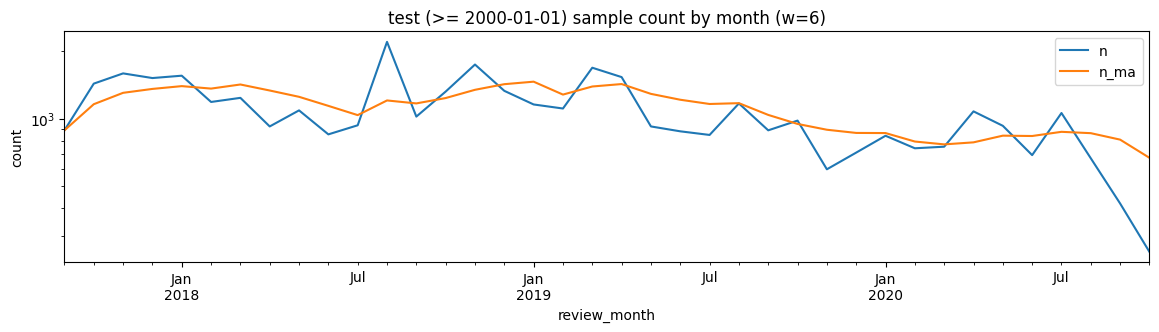

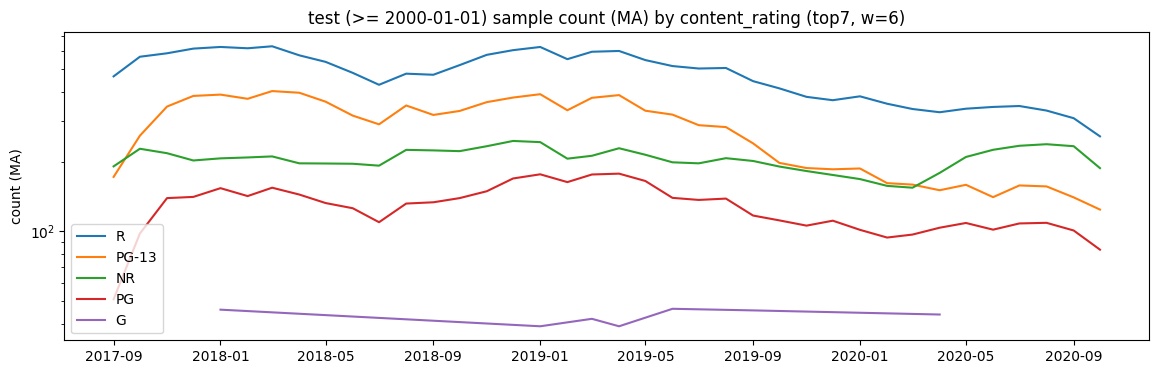

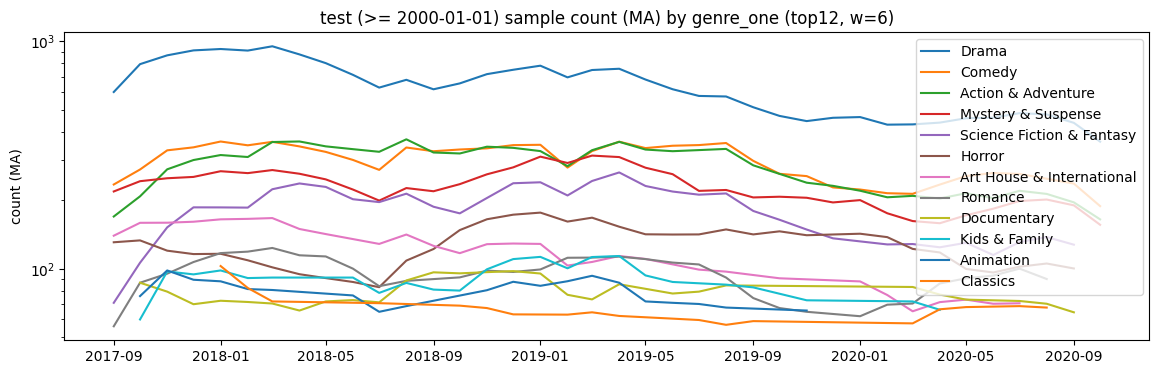

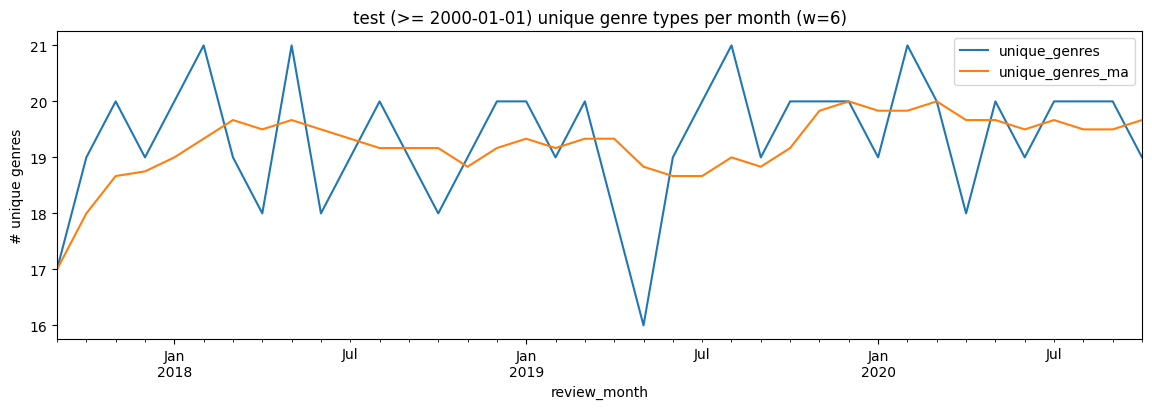

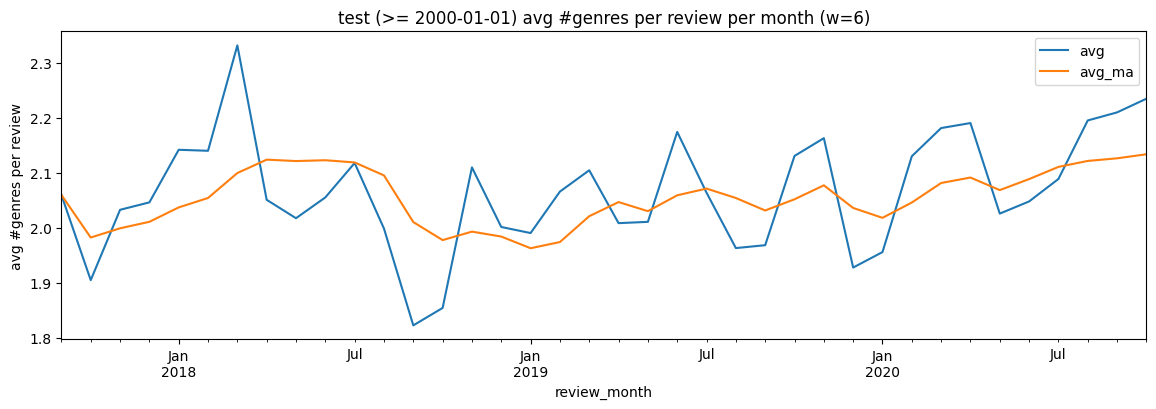

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


class ReviewTimeSeriesAnalyzer:
    """
    train/test の前処理と時系列プロットをまとめたユーティリティクラス

    - preprocess(): 日付のdatetime化 + 年/月列作成 + (trainなら) targetをint化 + review_date閾値でフィルタ
    - explode_genres(): genresを分割して1ジャンル=1行に展開
    - plot_*(): trainは target rate も、testは count のみで可視化
    - run_train_plots()/run_test_plots(): 一括実行
    """

    def __init__(
        self,
        min_review_date="2000-01-01",
        w=6,
        top_k_rating=10,
        top_k_genre=12,
        min_n_per_month_rating=30,
        min_n_per_month_genre=50,
        log_count=True,
    ):
        self.min_review_date = min_review_date
        self.w = w
        self.top_k_rating = top_k_rating
        self.top_k_genre = top_k_genre
        self.min_n_per_month_rating = min_n_per_month_rating
        self.min_n_per_month_genre = min_n_per_month_genre
        self.log_count = log_count

    # -------------------------
    # Preprocess
    # -------------------------
    def preprocess(
        self,
        df: pd.DataFrame,
        review_col="review_date",
        release_col="original_release_date",
        drop_na_review=True,
        add_time_cols=True,
        make_target_int=True,
    ) -> pd.DataFrame:
        d = df.copy()

        # datetime化（元列は残す）
        d["review_date_dt"] = pd.to_datetime(d[review_col], errors="coerce")
        d["release_date_dt"] = pd.to_datetime(d[release_col], errors="coerce")

        if drop_na_review:
            d = d[d["review_date_dt"].notna()].copy()

        if self.min_review_date is not None:
            min_dt = pd.to_datetime(self.min_review_date)
            d = d[d["review_date_dt"] >= min_dt].copy()

        if add_time_cols:
            d["review_year"] = d["review_date_dt"].dt.year
            d["review_month"] = d["review_date_dt"].dt.to_period("M").dt.to_timestamp()
            d["release_year"] = d["release_date_dt"].dt.year
            d["release_month"] = d["release_date_dt"].dt.to_period("M").dt.to_timestamp()

        if make_target_int and ("target" in d.columns):
            d["target"] = d["target"].astype(int)

        return d.reset_index(drop=True)

    def explode_genres(self, df: pd.DataFrame, genres_col="genres", out_col="genre_one") -> pd.DataFrame:
        d = df.copy()
        d[genres_col] = d[genres_col].fillna("").astype(str)
        # 区切り統一（, | ; をカンマ扱いに）
        d[genres_col] = d[genres_col].str.replace(r"[|;]", ",", regex=True)

        d[out_col] = d[genres_col].str.split(",")
        d = d.explode(out_col)
        d[out_col] = d[out_col].astype(str).str.strip()
        d = d[d[out_col] != ""].copy()

        return d.reset_index(drop=True)

    # -------------------------
    # Core aggregations
    # -------------------------
    def _monthly_rate_and_count(self, df: pd.DataFrame, date_col="review_month", target_col="target") -> pd.DataFrame:
        d = df.dropna(subset=[date_col]).copy()
        monthly = d.groupby(date_col)[target_col].agg(rate="mean", n="size").sort_index()
        monthly["rate_ma"] = monthly["rate"].rolling(self.w, min_periods=1).mean()
        monthly["n_ma"] = monthly["n"].rolling(self.w, min_periods=1).mean()
        return monthly

    def _monthly_count_only(self, df: pd.DataFrame, date_col="review_month") -> pd.DataFrame:
        d = df.dropna(subset=[date_col]).copy()
        monthly = d.groupby(date_col).size().to_frame("n").sort_index()
        monthly["n_ma"] = monthly["n"].rolling(self.w, min_periods=1).mean()
        return monthly

    def _by_category_rate_and_count(
        self,
        df: pd.DataFrame,
        cat_col: str,
        date_col="review_month",
        target_col="target",
        top_k=8,
        min_n_per_month=30,
    ) -> pd.DataFrame:
        d = df.dropna(subset=[date_col]).copy()
        d[cat_col] = d[cat_col].fillna("missing").astype(str)

        top_cats = d[cat_col].value_counts().head(top_k).index.tolist()
        d = d[d[cat_col].isin(top_cats)].copy()

        g = (
            d.groupby([date_col, cat_col])[target_col]
            .agg(rate="mean", n="size")
            .reset_index()
            .sort_values(date_col)
        )
        g = g[g["n"] >= min_n_per_month].copy()
        g["rate_ma"] = g.groupby(cat_col)["rate"].transform(lambda s: s.rolling(self.w, min_periods=1).mean())
        g["n_ma"] = g.groupby(cat_col)["n"].transform(lambda s: s.rolling(self.w, min_periods=1).mean())
        return g, top_cats

    def _by_category_count_only(
        self,
        df: pd.DataFrame,
        cat_col: str,
        date_col="review_month",
        top_k=8,
        min_n_per_month=30,
    ) -> pd.DataFrame:
        d = df.dropna(subset=[date_col]).copy()
        d[cat_col] = d[cat_col].fillna("missing").astype(str)

        top_cats = d[cat_col].value_counts().head(top_k).index.tolist()
        d = d[d[cat_col].isin(top_cats)].copy()

        g = (
            d.groupby([date_col, cat_col])
            .size()
            .reset_index(name="n")
            .sort_values(date_col)
        )
        g = g[g["n"] >= min_n_per_month].copy()
        g["n_ma"] = g.groupby(cat_col)["n"].transform(lambda s: s.rolling(self.w, min_periods=1).mean())
        return g, top_cats

    def _genre_growth_tables(self, df: pd.DataFrame, date_col="review_month", genres_col="genres"):
        d = df.dropna(subset=[date_col]).copy()

        # unique genre types per month
        gexp = self.explode_genres(d, genres_col=genres_col, out_col="genre_one")
        unique_df = gexp.groupby(date_col)["genre_one"].nunique().sort_index().to_frame("unique_genres")
        unique_df["unique_genres_ma"] = unique_df["unique_genres"].rolling(self.w, min_periods=1).mean()

        # avg genres per review
        s = d[genres_col].fillna("").astype(str).str.replace(r"[|;]", ",", regex=True)
        d["genre_count"] = s.apply(lambda x: len([t for t in x.split(",") if t.strip() != ""]))
        count_df = d.groupby(date_col)["genre_count"].agg(avg="mean", med="median", n="size").sort_index()
        count_df["avg_ma"] = count_df["avg"].rolling(self.w, min_periods=1).mean()

        return unique_df, count_df

    # -------------------------
    # Plot helpers
    # -------------------------
    def _plot_rate_and_count(self, monthly: pd.DataFrame, title_prefix: str):
        ax = monthly[["rate", "rate_ma"]].plot(figsize=(14, 4), title=f"{title_prefix} target rate by month (w={self.w})")
        ax.set_ylabel("target=1 rate")
        plt.show()

        ax2 = monthly[["n", "n_ma"]].plot(figsize=(14, 3), title=f"{title_prefix} sample count by month (w={self.w})")
        ax2.set_ylabel("count")
        if self.log_count:
            ax2.set_yscale("log")
        plt.show()

    def _plot_count_only(self, monthly: pd.DataFrame, title_prefix: str):
        ax = monthly[["n", "n_ma"]].plot(figsize=(14, 3), title=f"{title_prefix} sample count by month (w={self.w})")
        ax.set_ylabel("count")
        if self.log_count:
            ax.set_yscale("log")
        plt.show()

    def _plot_category_rate(self, g: pd.DataFrame, top_cats, cat_col: str, date_col="review_month", title_prefix=""):
        plt.figure(figsize=(14, 5))
        for c in top_cats:
            sub = g[g[cat_col] == c]
            if len(sub) == 0:
                continue
            plt.plot(sub[date_col], sub["rate_ma"], label=c)
        plt.title(f"{title_prefix} target rate (MA) by {cat_col} (top{len(top_cats)}, w={self.w})")
        plt.ylabel("target=1 rate (MA)")
        plt.legend()
        plt.show()

        plt.figure(figsize=(14, 4))
        for c in top_cats:
            sub = g[g[cat_col] == c]
            if len(sub) == 0:
                continue
            plt.plot(sub[date_col], sub["n_ma"], label=c)
        plt.title(f"{title_prefix} sample count (MA) by {cat_col} (top{len(top_cats)}, w={self.w})")
        plt.ylabel("count (MA)")
        if self.log_count:
            plt.yscale("log")
        plt.legend()
        plt.show()

    def _plot_category_count(self, g: pd.DataFrame, top_cats, cat_col: str, date_col="review_month", title_prefix=""):
        plt.figure(figsize=(14, 4))
        for c in top_cats:
            sub = g[g[cat_col] == c]
            if len(sub) == 0:
                continue
            plt.plot(sub[date_col], sub["n_ma"], label=c)
        plt.title(f"{title_prefix} sample count (MA) by {cat_col} (top{len(top_cats)}, w={self.w})")
        plt.ylabel("count (MA)")
        if self.log_count:
            plt.yscale("log")
        plt.legend()
        plt.show()

    def _plot_genre_growth(self, unique_df: pd.DataFrame, count_df: pd.DataFrame, title_prefix: str):
        ax = unique_df[["unique_genres", "unique_genres_ma"]].plot(
            figsize=(14, 4),
            title=f"{title_prefix} unique genre types per month (w={self.w})",
        )
        ax.set_ylabel("# unique genres")
        plt.show()

        ax2 = count_df[["avg", "avg_ma"]].plot(
            figsize=(14, 4),
            title=f"{title_prefix} avg #genres per review per month (w={self.w})",
        )
        ax2.set_ylabel("avg #genres per review")
        plt.show()

    # -------------------------
    # Public: run plots
    # -------------------------
    def run_train_plots(self, train_df: pd.DataFrame, title_prefix="train"):
        """
        train用：target rate + count / content_rating別 / genre別 / genre growth
        Returns:
            dict of aggregated tables
        """
        train_p = self.preprocess(train_df, make_target_int=True)

        # 全体（月次 rate & n）
        monthly_all = self._monthly_rate_and_count(train_p)
        self._plot_rate_and_count(monthly_all, f"{title_prefix} (>= {self.min_review_date})")

        # content_rating別（月次 rate & n）
        rating_g, rating_top = self._by_category_rate_and_count(
            train_p,
            cat_col="content_rating",
            top_k=self.top_k_rating,
            min_n_per_month=self.min_n_per_month_rating,
        )
        self._plot_category_rate(
            rating_g, rating_top, cat_col="content_rating", title_prefix=f"{title_prefix} (>= {self.min_review_date})"
        )

        # genres別（explodeして月次 rate & n）
        train_gen = self.explode_genres(train_p, "genres", "genre_one")
        genre_g, genre_top = self._by_category_rate_and_count(
            train_gen,
            cat_col="genre_one",
            top_k=self.top_k_genre,
            min_n_per_month=self.min_n_per_month_genre,
        )
        self._plot_category_rate(
            genre_g, genre_top, cat_col="genre_one", title_prefix=f"{title_prefix} (>= {self.min_review_date})"
        )

        # ジャンル増加（unique / avg genres per review）
        unique_df, count_df = self._genre_growth_tables(train_p)
        self._plot_genre_growth(unique_df, count_df, f"{title_prefix} (>= {self.min_review_date})")

        return {
            "train_p": train_p,
            "monthly_all": monthly_all,
            "rating_ts": rating_g,
            "genre_ts": genre_g,
            "unique_genres_df": unique_df,
            "genre_count_df": count_df,
        }

    def run_test_plots(self, test_df: pd.DataFrame, title_prefix="test"):
        """
        test用：countのみ / content_rating別 count / genre別 count / genre growth
        Returns:
            dict of aggregated tables
        """
        test_p = self.preprocess(test_df, make_target_int=False)

        # 全体（月次 n）
        monthly_all = self._monthly_count_only(test_p)
        self._plot_count_only(monthly_all, f"{title_prefix} (>= {self.min_review_date})")

        # content_rating別（月次 n）
        rating_g, rating_top = self._by_category_count_only(
            test_p,
            cat_col="content_rating",
            top_k=self.top_k_rating,
            min_n_per_month=self.min_n_per_month_rating,
        )
        self._plot_category_count(
            rating_g, rating_top, cat_col="content_rating", title_prefix=f"{title_prefix} (>= {self.min_review_date})"
        )

        # genres別（explodeして月次 n）
        test_gen = self.explode_genres(test_p, "genres", "genre_one")
        genre_g, genre_top = self._by_category_count_only(
            test_gen,
            cat_col="genre_one",
            top_k=self.top_k_genre,
            min_n_per_month=self.min_n_per_month_genre,
        )
        self._plot_category_count(
            genre_g, genre_top, cat_col="genre_one", title_prefix=f"{title_prefix} (>= {self.min_review_date})"
        )

        # ジャンル増加（unique / avg genres per review）※target不要
        unique_df, count_df = self._genre_growth_tables(test_p)
        self._plot_genre_growth(unique_df, count_df, f"{title_prefix} (>= {self.min_review_date})")

        return {
            "test_p": test_p,
            "monthly_all": monthly_all,
            "rating_ts": rating_g,
            "genre_ts": genre_g,
            "unique_genres_df": unique_df,
            "genre_count_df": count_df,
        }


# =========================
# Usage
# =========================
analyzer = ReviewTimeSeriesAnalyzer(
    min_review_date="2000-01-01",
    w=6,
    top_k_rating=10,
    top_k_genre=12,
    min_n_per_month_rating=30,
    min_n_per_month_genre=50,
    log_count=True,
)

train_outputs = analyzer.run_train_plots(train, title_prefix="train")
test_outputs  = analyzer.run_test_plots(test,  title_prefix="test")

In [16]:
train['publisher_name']

0                          Urban Cinefile
1                          Urban Cinefile
2                        Associated Press
3                          Slant Magazine
4                        Arizona Republic
                       ...               
653502                           PopcornQ
653503                    ColeSmithey.com
653504    Mountain Xpress (Asheville, NC)
653505      Dennis Schwartz Movie Reviews
653506            Sarasota Herald-Tribune
Name: publisher_name, Length: 653507, dtype: object

In [17]:
train.columns

Index(['ID', 'rotten_tomatoes_link', 'critic_name', 'top_critic',
       'publisher_name', 'review_date', 'movie_title', 'movie_info',
       'content_rating', 'genres', 'directors', 'authors', 'actors',
       'original_release_date', 'runtime', 'production_company', 'target'],
      dtype='object')

In [21]:
import pandas as pd
import numpy as np

class PublisherOverlapAnalyzer:
    """
    train/test の publisher_name 重複・カバレッジ・頻度・(train側)target率の偏りをまとめて分析するクラス
    """

    def __init__(
        self,
        publisher_col="publisher_name",
        target_col="target",
        missing_token="missing",
        strip=True,
    ):
        self.publisher_col = publisher_col
        self.target_col = target_col
        self.missing_token = missing_token
        self.strip = strip

    # -------------------------
    # Internal helpers
    # -------------------------
    def _normalize_publisher(self, s: pd.Series) -> pd.Series:
        s = s.fillna(self.missing_token).astype(str)
        if self.strip:
            s = s.str.strip()
        return s

    def _prepare(self, train: pd.DataFrame, test: pd.DataFrame):
        tr = train.copy()
        te = test.copy()
        tr[self.publisher_col] = self._normalize_publisher(tr[self.publisher_col])
        te[self.publisher_col] = self._normalize_publisher(te[self.publisher_col])
        return tr, te

    # -------------------------
    # Public APIs
    # -------------------------
    def overlap_summary(self, train: pd.DataFrame, test: pd.DataFrame) -> dict:
        tr, te = self._prepare(train, test)

        tr_set = set(tr[self.publisher_col].unique())
        te_set = set(te[self.publisher_col].unique())
        inter = tr_set & te_set
        union = tr_set | te_set

        in_train_mask = te[self.publisher_col].isin(inter)

        return {
            "train_unique_publishers": len(tr_set),
            "test_unique_publishers": len(te_set),
            "intersection_unique_publishers": len(inter),
            "union_unique_publishers": len(union),
            "jaccard(inter/union)": (len(inter) / len(union)) if len(union) else 0.0,
            "test_rows_total": int(len(te)),
            "test_rows_from_shared_publishers": int(in_train_mask.sum()),
            "test_rows_from_test_only_publishers": int((~in_train_mask).sum()),
            "test_row_coverage_in_train_publishers": float(in_train_mask.mean()),
        }

    def top_shared_publishers(self, train: pd.DataFrame, test: pd.DataFrame, k=30) -> pd.DataFrame:
        tr, te = self._prepare(train, test)

        tr_set = set(tr[self.publisher_col].unique())
        te_set = set(te[self.publisher_col].unique())
        shared = tr_set & te_set

        tr_counts = tr[self.publisher_col].value_counts()
        te_counts = te[self.publisher_col].value_counts()

        shared_df = pd.DataFrame({
            "test_count": te_counts.loc[te_counts.index.intersection(shared)],
            "train_count": tr_counts.loc[tr_counts.index.intersection(shared)],
        }).fillna(0).astype(int)

        if shared_df["test_count"].sum() > 0:
            shared_df["test_share"] = shared_df["test_count"] / shared_df["test_count"].sum()
        else:
            shared_df["test_share"] = 0.0

        return shared_df.sort_values("test_count", ascending=False).head(k)

    def top_test_only_publishers(self, train: pd.DataFrame, test: pd.DataFrame, k=30) -> pd.DataFrame:
        tr, te = self._prepare(train, test)

        tr_set = set(tr[self.publisher_col].unique())
        te_set = set(te[self.publisher_col].unique())
        shared = tr_set & te_set

        te_counts = te[self.publisher_col].value_counts()
        only = te_counts[~te_counts.index.isin(shared)].head(k).to_frame("test_only_count")
        return only

    def top_train_only_publishers(self, train: pd.DataFrame, test: pd.DataFrame, k=30) -> pd.DataFrame:
        tr, te = self._prepare(train, test)

        tr_set = set(tr[self.publisher_col].unique())
        te_set = set(te[self.publisher_col].unique())
        shared = tr_set & te_set

        tr_counts = tr[self.publisher_col].value_counts()
        only = tr_counts[~tr_counts.index.isin(shared)].head(k).to_frame("train_only_count")
        return only

    def publisher_target_extremes(self, train: pd.DataFrame, min_n=200, k=30) -> tuple[pd.DataFrame, float]:
        """
        train側だけで、publisherごとの target率が全体平均との差が大きい順を返す。
        """
        if self.target_col not in train.columns:
            raise ValueError(f"train must have '{self.target_col}' column.")

        d = train[[self.publisher_col, self.target_col]].copy()
        d[self.publisher_col] = self._normalize_publisher(d[self.publisher_col])
        d[self.target_col] = d[self.target_col].astype(int)

        global_rate = float(d[self.target_col].mean())

        stats = d.groupby(self.publisher_col)[self.target_col].agg(rate="mean", n="size")
        stats = stats[stats["n"] >= min_n].copy()
        stats["rate_gap_from_global"] = stats["rate"] - global_rate

        # 絶対差が大きい順に上位k
        stats = stats.reindex(stats["rate_gap_from_global"].abs().sort_values(ascending=False).index).head(k)

        return stats.sort_values("rate_gap_from_global", ascending=False), global_rate

    def run_all(self, train: pd.DataFrame, test: pd.DataFrame, k=30, min_n=200) -> dict:
        """
        主要な分析をまとめて実行して返す
        """
        out = {}
        out["summary"] = self.overlap_summary(train, test)
        out["top_shared"] = self.top_shared_publishers(train, test, k=k)
        out["top_test_only"] = self.top_test_only_publishers(train, test, k=k)
        out["top_train_only"] = self.top_train_only_publishers(train, test, k=k)

        if self.target_col in train.columns:
            extremes, global_rate = self.publisher_target_extremes(train, min_n=min_n, k=k)
            out["publisher_extremes"] = extremes
            out["global_target_rate"] = global_rate

        return out


# =========================
# Usage
# =========================
analyzer = PublisherOverlapAnalyzer(publisher_col="publisher_name", target_col="target")
results = analyzer.run_all(train, test, k=30, min_n=200)

print(results["summary"])
display(results["top_shared"])
display(results["top_test_only"])
display(results["top_train_only"])
display(results.get("publisher_extremes"))
print("global target rate:", results.get("global_target_rate"))

{'train_unique_publishers': 1041, 'test_unique_publishers': 799, 'intersection_unique_publishers': 590, 'union_unique_publishers': 1250, 'jaccard(inter/union)': 0.472, 'test_rows_total': 40716, 'test_rows_from_shared_publishers': 33876, 'test_rows_from_test_only_publishers': 6840, 'test_row_coverage_in_train_publishers': 0.8320070733863837}


,test_count,train_count,test_share
publisher_name,,,
CineVue,846,172,0.024973
Herald Sun (Australia),681,727,0.020103
Espinof,580,314,0.017121
Reel Film Reviews,514,4103,0.015173
The Spectator,511,244,0.015084
The List,509,1310,0.015025
Los Angeles Times,479,7204,0.014140
Maclean's Magazine,454,76,0.013402
Hollywood Reporter,451,6065,0.013313


,test_only_count
publisher_name,
Film Frenzy,583
Flickering Myth,540
The Last Thing I See,539
Assignment X,538
Alternate Ending,291
Way Too Indie,275
DCist,260
The Public (Buffalo),218
Moveable Fest,213


,train_only_count
publisher_name,
Compuserve,3351
Internet Reviews,2934
TheMovieReport.com,2860
Antagony & Ecstasy,2379
Jam! Movies,2225
About.com,2083
Miami Herald,1937
Metromix.com,1871
Rochester Democrat and Chronicle,1632


,rate,n,rate_gap_from_global
publisher_name,,,
AMC Filmsite,1.000000,290,0.380937
Baret News,0.915385,390,0.296322
MediaMikes,0.885387,349,0.266324
Newcity,0.881671,431,0.262608
Projected Figures,0.881148,244,0.262085
Nolan's Pop Culture Review,0.880478,502,0.261415
Cinema Autopsy,0.872017,461,0.252954
Seanax.com,0.869464,429,0.250401
Real.com,0.863281,256,0.244218


global target rate: 0.6190629939694602


review_dateが明確に時系列でわかれており、さらにtrainとtestの間には1年間の空白がある。
trainとtestで時系列で分かれているため、レビュー傾向が変わっている可能性がある。

In [22]:
# train/testの映画数・批評家数・メディア数を比較
for col in ["rotten_tomatoes_link", "critic_name", "publisher_name", "directors", "production_company"]:
    n_train = train[col].nunique()
    n_test = test[col].nunique()
    overlap = set(train[col].dropna()) & set(test[col].dropna())
    test_only = n_test - len(overlap)
    print(f"{col}: train={n_train:,}, test={n_test:,}, 重複={len(overlap):,}, test固有={test_only:,}")

rotten_tomatoes_link: train=15,058, test=9,333, 重複=7,301, test固有=2,032
critic_name: train=1,573, test=1,483, 重複=1,483, test固有=0
publisher_name: train=1,041, test=799, 重複=590, test固有=209
directors: train=7,515, test=4,893, 重複=3,835, test固有=1,058
production_company: train=2,620, test=1,601, 重複=1,319, test固有=282


映画については、testにしか出てこない映画も1/5以上存在しており、trainデータでは未知の映画のレビューを予測する必要がある。

一方で、批評家についてはtestのみに出てくる人は0人であり、trainデータでは未知の批評家のレビューを予測する必要はない。

In [23]:
# top_criticの分析
print("top_criticごとのFresh率:")
tc_stats = train.groupby("top_critic").agg(
    count=("target", "size"),
    fresh_rate=("target", "mean")
)
display(tc_stats)

top_criticごとのFresh率:


,count,fresh_rate
top_critic,,
False,451326,0.635383
True,202181,0.582631


In [24]:
import pandas as pd

# 前提: train DataFrame, target(0/1), content_rating, publisher_name, top_critic がある想定
# 表示を見やすく（任意）
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

# =============
# 0) ベース：content_rating ごと
# =============
cr_stats = train.groupby("content_rating").agg(
    count=("target", "size"),
    fresh_rate=("target", "mean")
).sort_values("count", ascending=False)

print("content_ratingごとのFresh率と件数:")
display(cr_stats)

# =========================================================
# 3) top_critic を絡める：content_rating × top_critic
# =========================================================
cr_top = train.groupby(["content_rating", "top_critic"]).agg(
    count=("target", "size"),
    fresh_rate=("target", "mean")
).reset_index()

# 見やすくピボット（top_criticごとのFresh率/件数）
cr_top_rate_pivot = cr_top.pivot(index="content_rating", columns="top_critic", values="fresh_rate")
cr_top_count_pivot = cr_top.pivot(index="content_rating", columns="top_critic", values="count")

print("content_rating × top_critic のFresh率（pivot）:")
display(cr_top_rate_pivot.sort_index())

print("content_rating × top_critic の件数（pivot）:")
display(cr_top_count_pivot.sort_index())

content_ratingごとのFresh率と件数:


,count,fresh_rate
content_rating,,
R,283773,0.624309
PG-13,199802,0.544709
PG,80917,0.615952
NR,69284,0.783918
G,18088,0.731479
NC17,1606,0.722291


content_rating × top_critic のFresh率（pivot）:


top_critic,False,True
content_rating,,
G,0.747063,0.692308
NC17,0.748162,0.667954
NR,0.804076,0.750480
PG,0.636077,0.567956
PG-13,0.561134,0.505670
R,0.643247,0.581738


content_rating × top_critic の件数（pivot）:


top_critic,False,True
content_rating,,
G,12940,5148
NC17,1088,518
NR,43226,26058
PG,57012,23905
PG-13,140633,59169
R,196402,87371


In [25]:
import pandas as pd

# ----------------------------
# 0) 共通：前処理（おすすめ）
# ----------------------------
df = train.copy()

# content_rating はほぼ埋まってるけど、固定軸として欠損も見たいなら "(missing)" に寄せる
df["content_rating"] = df["content_rating"].fillna("(missing)")

# object列の欠損を "(missing)" に寄せたい場合（任意）
# ※genres / directors など欠損がある列に効く
obj_cols = df.select_dtypes(include=["object"]).columns
df[obj_cols] = df[obj_cols].fillna("(missing)")


# ---------------------------------------------------
# 1) テンプレ関数：content_rating × feature の集計
# ---------------------------------------------------
def cr_x_feature_stats(
    df: pd.DataFrame,
    feature: str,
    min_count: int = 200,
    top_n: int = 50,
    sort_by: str = "count",      # "count" or "fresh_rate"
    ascending: bool = False
) -> pd.DataFrame:
    """
    content_rating を固定軸に、指定 feature と絡めて
    件数 / Fresh率 / top_critic比率（featureがtop_criticじゃない時）を集計。
    """
    group_cols = ["content_rating", feature]

    agg = {
        "count": ("target", "size"),
        "fresh_rate": ("target", "mean"),
    }
    # top_critic列があり、feature自体がtop_criticでないなら参考として比率も出す
    if "top_critic" in df.columns and feature != "top_critic":
        agg["top_critic_rate"] = ("top_critic", "mean")

    out = (
        df.groupby(group_cols, dropna=False)
          .agg(**agg)
          .reset_index()
    )

    # ノイズ削減
    out = out[out["count"] >= min_count]

    # 並び替え
    if sort_by == "fresh_rate":
        out = out.sort_values(["fresh_rate", "count"], ascending=[ascending, False])
    else:
        out = out.sort_values("count", ascending=ascending)

    return out.head(top_n)


# ---------------------------------------------------
# 2) まず鉄板：content_rating × top_critic（pivotも作る）
# ---------------------------------------------------
cr_top = (
    df.groupby(["content_rating", "top_critic"], dropna=False)
      .agg(count=("target", "size"), fresh_rate=("target", "mean"))
      .reset_index()
)

cr_top_rate_pivot = cr_top.pivot(index="content_rating", columns="top_critic", values="fresh_rate")
cr_top_count_pivot = cr_top.pivot(index="content_rating", columns="top_critic", values="count")

print("content_rating × top_critic Fresh率（pivot）")
display(cr_top_rate_pivot)

print("content_rating × top_critic 件数（pivot）")
display(cr_top_count_pivot)


# ---------------------------------------------------
# 3) content_rating × publisher_name（件数上位だけ）
# ---------------------------------------------------
print("content_rating × publisher_name（件数上位）")
display(cr_x_feature_stats(df, "publisher_name", min_count=300, top_n=50, sort_by="count", ascending=False))


# ---------------------------------------------------
# 4) 他の特徴量も同じノリで回す（例）
# ---------------------------------------------------
features_to_check = [
    "genres",
    "directors",
    "authors",
    "production_company",
    # "actors",  # 文字列が長くカテゴリが膨大なので、やるならmin_countをかなり上げるの推奨
    # "movie_info"  # 同上
]

for feat in features_to_check:
    print(f"\ncontent_rating × {feat}（count>=500 の件数上位）")
    display(cr_x_feature_stats(df, feat, min_count=500, top_n=30, sort_by="count", ascending=False))


# ---------------------------------------------------
# 5) 「content_ratingごとに、featureの上位カテゴリだけ」も見たい版
#    （例：各content_ratingで publisher 上位10個だけ）
# ---------------------------------------------------
def top_k_per_content_rating(df: pd.DataFrame, feature: str, k: int = 10, min_count: int = 100) -> pd.DataFrame:
    tmp = (
        df.groupby(["content_rating", feature], dropna=False)
          .agg(count=("target", "size"), fresh_rate=("target", "mean"))
          .reset_index()
    )
    tmp = tmp[tmp["count"] >= min_count]

    # content_ratingごとに count 上位k
    tmp["rank_in_cr"] = tmp.groupby("content_rating")["count"].rank(method="first", ascending=False)
    return tmp[tmp["rank_in_cr"] <= k].sort_values(["content_rating", "count"], ascending=[True, False])

print("\n各content_ratingごとに publisher_name 上位10個（count>=200）")
display(top_k_per_content_rating(df, "publisher_name", k=10, min_count=200))

content_rating × top_critic Fresh率（pivot）


top_critic,False,True
content_rating,,
(missing),0.560000,0.583333
G,0.747063,0.692308
NC17,0.748162,0.667954
NR,0.804076,0.750480
PG,0.636077,0.567956
PG-13,0.561134,0.505670
R,0.643247,0.581738


content_rating × top_critic 件数（pivot）


top_critic,False,True
content_rating,,
(missing),25,12
G,12940,5148
NC17,1088,518
NR,43226,26058
PG,57012,23905
PG-13,140633,59169
R,196402,87371


content_rating × publisher_name（件数上位）


...

,content_rating,authors,count,fresh_rate,top_critic_rate
610,NR,(missing),10841,0.830551,0.426437
7592,R,(missing),8388,0.727587,0.327730
5349,PG-13,(missing),6100,0.721639,0.337869
3643,PG,(missing),3959,0.777216,0.351099
7575,PG-13,Woody Allen,1640,0.641463,0.304268
1,G,(missing),1190,0.779832,0.347899
11101,R,Quentin Tarantino,1187,0.836563,0.253580
6671,PG-13,M. Night Shyamalan,1068,0.620787,0.252809
10965,R,Paul Thomas Anderson,921,0.825190,0.263844
5956,PG-13,Ehren Kruger,896,0.376116,0.264509



content_rating × production_company（count>=500 の件数上位）


,content_rating,production_company,count,fresh_rate,top_critic_rate
2511,PG-13,Warner Bros. Pictures,17018,0.482607,0.273475
3591,R,Warner Bros. Pictures,16818,0.552741,0.276014
2484,PG-13,Universal Pictures,15772,0.534745,0.271747
3552,R,Universal Pictures,15698,0.606638,0.271945
2006,PG-13,20th Century Fox,15259,0.521790,0.270201
3417,R,Sony Pictures Classics,13909,0.755051,0.335970
2340,PG-13,Paramount Pictures,13178,0.558734,0.278115
2421,PG-13,Sony Pictures,11168,0.488181,0.277042
3117,R,Magnolia Pictures,10196,0.674186,0.350137
2538,R,20th Century Fox,9535,0.555742,0.275931



各content_ratingごとに publisher_name 上位10個（count>=200）


,content_rating,publisher_name,count,fresh_rate,rank_in_cr
188,G,EmanuelLevy.Com,483,0.648033,1.0
403,G,New York Times,406,0.618227,2.0
624,G,Variety,338,0.718935,3.0
647,G,eFilmCritic.com,287,0.731707,4.0
166,G,Dennis Schwartz Movie Reviews,276,0.688406,5.0
98,G,Chicago Sun-Times,259,0.683398,6.0
137,G,Common Sense Media,255,0.862745,7.0
595,G,Time Out,252,0.698413,8.0
223,G,Filmcritic.com,250,0.628000,9.0
57,G,Arkansas Democrat-Gazette,248,0.661290,10.0


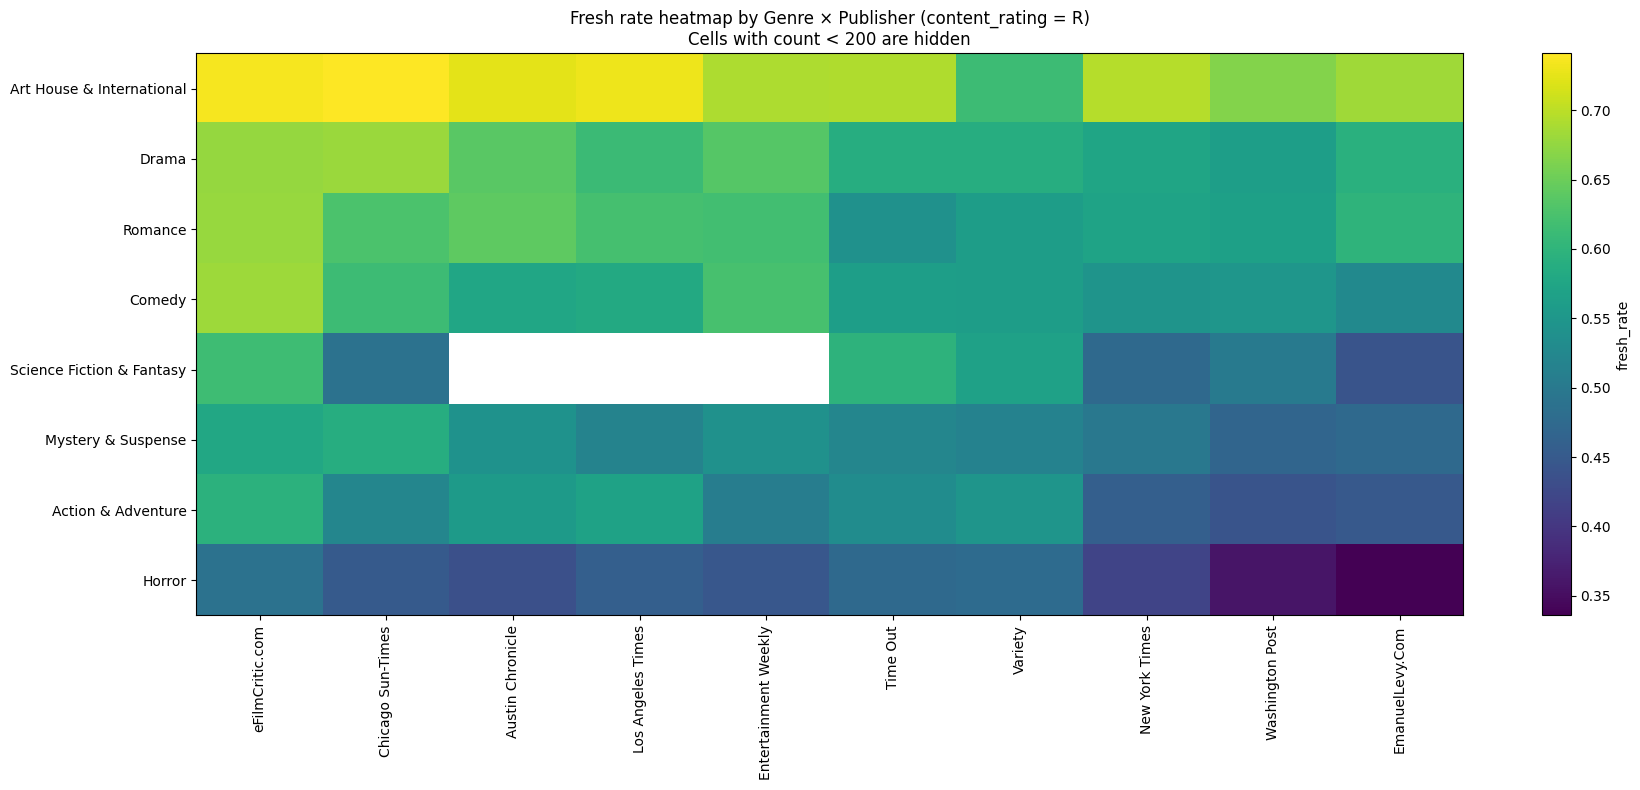

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========
# 設定（ここだけいじればOK）
# ==========
RATING = "R"          # 例: "R", "PG-13", "NR" など
TOP_PUB = 10          # 表示するpublisher数（多すぎると見づらい）
TOP_GEN = 8# 表示するgenre数
MIN_COUNT = 200       # (genre,publisher)の組合せの最低レビュー数（少ないとブレるので隠す）

df = train.copy()

# 欠損処理（genre欠損行は落とす。publisher/content_ratingは基本欠損なしの前提）
df = df[df["content_rating"].notna() & df["publisher_name"].notna() & df["genres"].notna()]

# content_rating 固定
df = df[df["content_rating"] == RATING]

# ==========
# genres を正規化（カンマ区切り想定）
# ==========
# 例: "Drama, Comedy" → ["Drama", "Comedy"] にして explode
df = df.assign(
    genre=df["genres"].str.split(",")
).explode("genre")

df["genre"] = df["genre"].str.strip()
df = df[df["genre"] != ""]  # 念のため空文字除外

# ==========
# 表示対象（上位publisher / 上位genre）を決める
# ==========
top_publishers = df["publisher_name"].value_counts().head(TOP_PUB).index
top_genres = df["genre"].value_counts().head(TOP_GEN).index

df_sub = df[df["publisher_name"].isin(top_publishers) & df["genre"].isin(top_genres)]

# ==========
# 集計：count と fresh_rate
# ==========
agg = (
    df_sub.groupby(["genre", "publisher_name"])
          .agg(count=("target", "size"), fresh_rate=("target", "mean"))
          .reset_index()
)

# ピボット（ヒートマップ用）
rate_mat = agg.pivot(index="genre", columns="publisher_name", values="fresh_rate")
count_mat = agg.pivot(index="genre", columns="publisher_name", values="count")

# サンプル数が少ないセルは NaN にして表示しない（ブレ対策）
rate_mat = rate_mat.mask(count_mat < MIN_COUNT)

# 行・列を「見やすい順」に並べる（任意：全体の平均fresh_rateで並べる）
rate_mat = rate_mat.loc[
    rate_mat.mean(axis=1).sort_values(ascending=False).index,
    rate_mat.mean(axis=0).sort_values(ascending=False).index
]

# ==========
# 1枚グラフ：ヒートマップ
# ==========
plt.figure(figsize=(1.2 * rate_mat.shape[1] + 6, 0.5 * rate_mat.shape[0] + 4))

# NaN を含むので masked array にして表示
im = plt.imshow(rate_mat.values, aspect="auto", interpolation="nearest")

plt.title(f"Fresh rate heatmap by Genre × Publisher (content_rating = {RATING})\n"
          f"Cells with count < {MIN_COUNT} are hidden")
plt.colorbar(im, label="fresh_rate")

plt.xticks(range(rate_mat.shape[1]), rate_mat.columns, rotation=90)
plt.yticks(range(rate_mat.shape[0]), rate_mat.index)

plt.tight_layout()
plt.show()

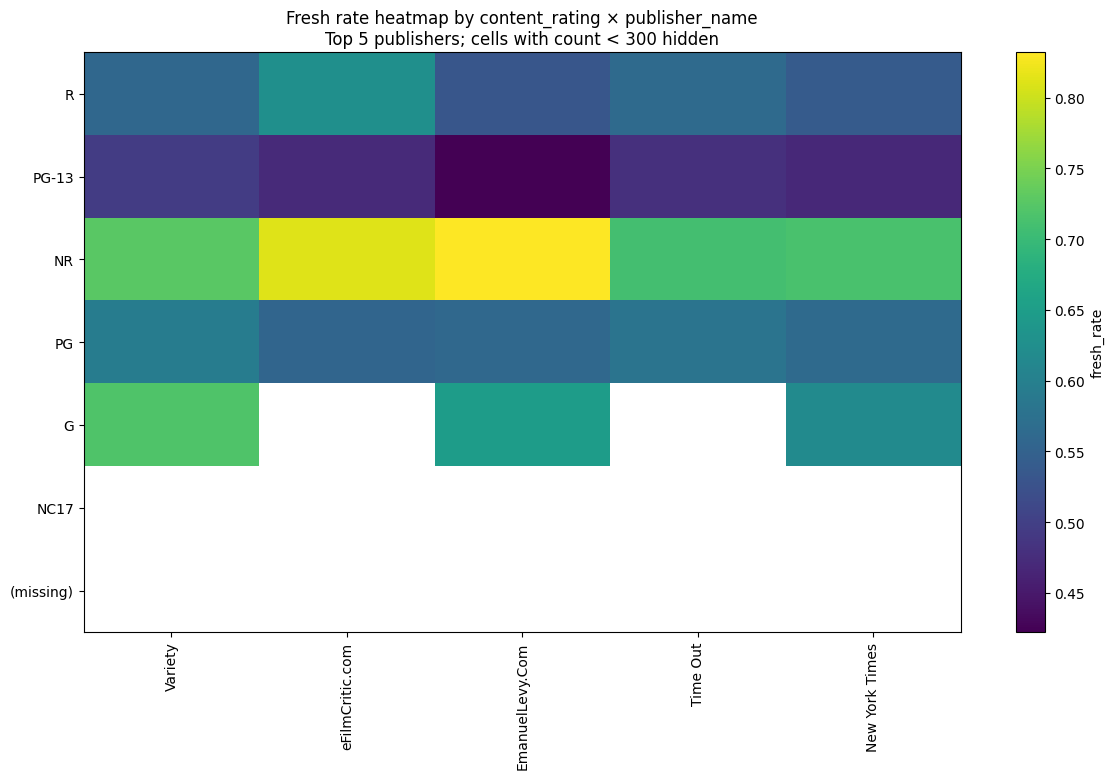

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========
# 設定（ここだけ調整すればOK）
# ==========
TOP_PUB = 5    # 表示するpublisher数（多いほど横が詰む）
MIN_COUNT = 300     # (content_rating,publisher) の最低件数。少ないセルは隠す

df = train.copy()

# 欠損処理（content_ratingは欠損14件だけなので missing 扱いにして残すのが楽）
df["content_rating"] = df["content_rating"].fillna("(missing)")

# ==========
# publisher を件数上位に絞る（見やすさのため）
# ==========
top_publishers = df["publisher_name"].value_counts().head(TOP_PUB).index
df_sub = df[df["publisher_name"].isin(top_publishers)]

# ==========
# 集計：count と fresh_rate
# ==========
agg = (
    df_sub.groupby(["content_rating", "publisher_name"], dropna=False)
          .agg(count=("target", "size"), fresh_rate=("target", "mean"))
          .reset_index()
)

# ピボット（ヒートマップ用）
rate_mat = agg.pivot(index="content_rating", columns="publisher_name", values="fresh_rate")
count_mat = agg.pivot(index="content_rating", columns="publisher_name", values="count")

# 件数が少ないセルは NaN にして非表示（ブレ防止）
rate_mat = rate_mat.mask(count_mat < MIN_COUNT)

# 並び順：見やすくするため、publisherは平均fresh_rateで、ratingは総件数で並べ替え（任意）
rate_mat = rate_mat.loc[
    df_sub["content_rating"].value_counts().index,  # ratingは母数の多い順
    rate_mat.mean(axis=0).sort_values(ascending=False).index  # publisherは平均Fresh率の高い順
]

# ==========
# 1枚グラフ：ヒートマップ
# ==========
plt.figure(figsize=(1.2 * rate_mat.shape[1] + 6, 0.7 * rate_mat.shape[0] + 3))

im = plt.imshow(rate_mat.values, aspect="auto", interpolation="nearest")
plt.colorbar(im, label="fresh_rate")

plt.title(
    f"Fresh rate heatmap by content_rating × publisher_name\n"
    f"Top {TOP_PUB} publishers; cells with count < {MIN_COUNT} hidden"
)

plt.xticks(range(rate_mat.shape[1]), rate_mat.columns, rotation=90)
plt.yticks(range(rate_mat.shape[0]), rate_mat.index)

plt.tight_layout()
plt.show()

top批評家は全体の1/3程度で、top批評家のほうが高評価している割合が少し高い


In [28]:
# content_ratingの分析
cr_stats = train.groupby("content_rating").agg(
    count=("target", "size"),
    fresh_rate=("target", "mean")
).sort_values("count", ascending=False)
print("content_ratingごとのFresh率と件数:")
display(cr_stats)

content_ratingごとのFresh率と件数:


,count,fresh_rate
content_rating,,
R,283773,0.624309
PG-13,199802,0.544709
PG,80917,0.615952
NR,69284,0.783918
G,18088,0.731479
NC17,1606,0.722291


In [29]:
# genresの分析
print("genresのサンプル:")
display(train["genres"].head(10))

# 個別ジャンルを展開して出現頻度を確認
all_genres = train["genres"].dropna().str.split(", ").explode()
genre_counts = all_genres.value_counts()
print(f"\nユニークジャンル数: {genre_counts.shape[0]}")
print("\nジャンル別の出現頻度:")
display(genre_counts)

genresのサンプル:


0    Action & Adventure, Comedy, Drama, Science Fic...
1    Action & Adventure, Comedy, Drama, Science Fic...
2    Action & Adventure, Comedy, Drama, Science Fic...
3    Action & Adventure, Comedy, Drama, Science Fic...
4    Action & Adventure, Comedy, Drama, Science Fic...
5    Action & Adventure, Comedy, Drama, Science Fic...
6    Action & Adventure, Comedy, Drama, Science Fic...
7    Action & Adventure, Comedy, Drama, Science Fic...
8    Action & Adventure, Comedy, Drama, Science Fic...
9    Action & Adventure, Comedy, Drama, Science Fic...
Name: genres, dtype: object


ユニークジャンル数: 21

ジャンル別の出現頻度:


genres
Drama                        367789
Comedy                       225832
Action & Adventure           168188
Mystery & Suspense           143652
Science Fiction & Fantasy     96994
Romance                       75380
Art House & International     70361
Horror                        58779
Kids & Family                 48257
Documentary                   47264
Special Interest              35563
Musical & Performing Arts     30294
Animation                     30225
Classics                      26411
Western                        7676
Sports & Fitness               6313
Television                     4842
Cult Movies                    2794
Faith & Spirituality           1756
Gay & Lesbian                  1056
Anime & Manga                   247
Name: count, dtype: int64

1映画に複数ジャンルが付与されるため、そのままではうまく活用できない。

そのため、one-hotエンコードで各ジャンルの有無をフラグ化する

In [30]:
# runtimeの分布とtargetとの関係
print("runtimeの基本統計量:")
display(train["runtime"].describe())

# runtimeをビン分割してFresh率を確認
train["runtime_bin"] = pd.cut(train["runtime"], bins=[0, 80, 100, 120, 150, 300])
rt_stats = train.groupby("runtime_bin", observed=True).agg(
    count=("target", "size"),
    fresh_rate=("target", "mean")
)
print("\nruntime帯ごとのFresh率:")
display(rt_stats)
train = train.drop(columns="runtime_bin")

runtimeの基本統計量:


count    649796.000000
mean        107.506641
std          18.879732
min           5.000000
25%          94.000000
50%         105.000000
75%         118.000000
max         266.000000
Name: runtime, dtype: float64


runtime帯ごとのFresh率:


,count,fresh_rate
runtime_bin,,
"(0, 80]",17705,0.716464
"(80, 100]",247721,0.578534
"(100, 120]",250285,0.611982
"(120, 150]",115786,0.681533
"(150, 300]",18299,0.765616


短い映画、および、長い映画では高評価率が高い

In [31]:
train.head()

,ID,rotten_tomatoes_link,critic_name,top_critic,publisher_name,review_date,movie_title,movie_info,content_rating,genres,directors,authors,actors,original_release_date,runtime,production_company,target
0,0,m/0814255,Andrew L. Urban,False,Urban Cinefile,2010-02-06,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,119.0,20th Century Fox,1
1,1,m/0814255,Louise Keller,False,Urban Cinefile,2010-02-06,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,119.0,20th Century Fox,1
2,2,m/0814255,David Germain,True,Associated Press,2010-02-10,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,119.0,20th Century Fox,0
3,3,m/0814255,Nick Schager,False,Slant Magazine,2010-02-10,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,119.0,20th Century Fox,0
4,4,m/0814255,Bill Goodykoontz,True,Arizona Republic,2010-02-10,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,119.0,20th Century Fox,1


## 3. 特徴量エンジニアリング

モデルに入力できる形式に変換します。

### 使用するカラムと作成する特徴量:

**数値特徴量:**
- `runtime`: 上映時間（分）
- `top_critic`: トップ批評家フラグ

**日付特徴量:**
- `review_year`, `review_month`, `review_dayofweek`: レビュー日時
- `movie_age_days`: 映画公開からレビューまでの日数

**カテゴリ特徴量（LightGBMのネイティブカテゴリ機能を利用）:**
- `content_rating`: レーティング（G, PG, R等）
- `publisher_name`: メディア出版社
- `directors`: 監督
- `production_company`: 制作会社

**ジャンル特徴量:**
- 主要ジャンル（Drama, Comedy等）のフラグ

In [32]:
def create_features(df):
    """
    特徴量を作成する関数
    
    Parameters:
        df: 入力データフレーム（trainまたはtest）
    Returns:
        特徴量を追加したデータフレーム
    """
    df = df.copy()
    
    # === 日付特徴量 ===
    df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce")
    df["review_year"] = df["review_date"].dt.year
    df["review_month"] = df["review_date"].dt.month
    df["review_dayofweek"] = df["review_date"].dt.dayofweek  # 0=月曜, 6=日曜
    
    # 映画年齢: 公開日からレビュー日までの日数
    # 新作映画か旧作映画かで批評傾向が異なる可能性
    df["original_release_date"] = pd.to_datetime(df["original_release_date"], errors="coerce")
    df["movie_age_days"] = (df["review_date"] - df["original_release_date"]).dt.days
    # 負の値（公開前レビュー）はNaNに
    df.loc[df["movie_age_days"] < 0, "movie_age_days"] = np.nan
    
    # === ジャンル特徴量 ===
    # 主要ジャンルをOne-hotエンコード
    major_genres = ["Drama", "Comedy", "Action", "Mystery", "Fantasy", "Romance", "Horror", "Documentary"]
    for genre in major_genres:
        df[f"genre_{genre}"] = df["genres"].fillna("").str.contains(genre, case=False).astype(int)
    
    # === カテゴリ特徴量 ===
    # LightGBMのネイティブカテゴリ機能を使うためcategory型に変換
    cat_cols = ["content_rating", "publisher_name"]
    for col in cat_cols:
        df[col] = df[col].fillna("missing").astype("category")
    
    return df

# 特徴量作成を実行
train = create_features(train)
test = create_features(test)

print("特徴量作成完了!")

特徴量作成完了!


In [33]:
# 作成した特徴量の確認
print("日付・映画年齢特徴量:")
display(train[["review_date", "review_year", "review_month", "review_dayofweek",
               "original_release_date", "movie_age_days"]].sample(5))


# ジャンル特徴量の確認
genre_cols = [col for col in train.columns if col.startswith("genre_")]
print("ジャンル特徴量:")
display(train[["genres"] + genre_cols].sample(5))

日付・映画年齢特徴量:


,review_date,review_year,review_month,review_dayofweek,original_release_date,movie_age_days
194175,2011-01-18,2011,1,1,2011-01-14,4.0
73887,2014-07-15,2014,7,1,2002-08-16,4351.0
273546,2013-04-24,2013,4,2,2013-05-03,NaN
54540,2011-09-08,2011,9,3,2011-09-09,NaN
21531,2003-05-20,2003,5,1,NaT,NaN


ジャンル特徴量:


,genres,genre_Drama,genre_Comedy,genre_Action,genre_Mystery,genre_Fantasy,genre_Romance,genre_Horror,genre_Documentary
59889,"Action & Adventure, Comedy",0,1,1,0,0,0,0,0
357977,"Comedy, Drama, Romance",1,1,0,0,0,1,0,0
436095,"Comedy, Drama",1,1,0,0,0,0,0,0
283399,"Art House & International, Drama, Romance",1,0,0,0,0,1,0,0
190977,"Drama, Romance",1,0,0,0,0,1,0,0


In [34]:
train.shape

(653507, 29)

In [35]:
train.columns

Index(['ID', 'rotten_tomatoes_link', 'critic_name', 'top_critic',
       'publisher_name', 'review_date', 'movie_title', 'movie_info',
       'content_rating', 'genres', 'directors', 'authors', 'actors',
       'original_release_date', 'runtime', 'production_company', 'target',
       'review_year', 'review_month', 'review_dayofweek', 'movie_age_days',
       'genre_Drama', 'genre_Comedy', 'genre_Action', 'genre_Mystery',
       'genre_Fantasy', 'genre_Romance', 'genre_Horror', 'genre_Documentary'],
      dtype='object')

In [36]:
test.shape

(40716, 28)

In [37]:
# モデルに使用する特徴量リスト
features = [
    # 数値特徴量
    #"runtime",
    "top_critic",
    
    # 日付特徴量
    #"review_year",
    #"review_month",
    #"review_dayofweek",
    #"movie_age_days",
    
    # カテゴリ特徴量（category型）
    "content_rating",
    #"publisher_name",
    
    # ジャンル特徴量
    #"genre_Drama",
    #"genre_Comedy",
    #"genre_Action",
    #"genre_Mystery",
    #"genre_Fantasy",
    #"genre_Romance",
    #"genre_Horror",
    #"genre_Documentary",
]

print(f"使用する特徴量: {len(features)}個")
for f in features:
    print(f"  - {f}")

使用する特徴量: 2個
  - top_critic
  - content_rating


In [38]:
# 特徴量の統計情報
display(train[features].describe(include="all"))

,top_critic,content_rating
count,653507,653507
unique,2,7
top,False,R
freq,451326,283773


movie_age_daysなどは、平均値だとかなり大きいが、中央値をみると、多くが公開直後のレビューだとわかる

## 4. モデル学習（5-Fold CV）

LightGBMを使って学習します。

### K-Fold Cross Validation とは？
- データを5つに分割し、4つで学習・1つで検証を5回繰り返し、5つのモデルを構築
- 各foldのモデルのスコアを平均して、testデータの予測を算出
- 過学習を防ぎ、安定した評価が可能

![image.png](attachment:image.png)

In [39]:
# 学習データの準備
X = train[features]
y = train["target"].values
X_test = test[features]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"X_test shape: {X_test.shape}")

X shape: (653507, 2)
y shape: (653507,)
X_test shape: (40716, 2)


In [40]:
# LightGBMのパラメータ
lgb_params = {
    "objective": "binary",      # 二値分類
    "metric": "auc",            # 評価指標
    "boosting_type": "gbdt",    # 勾配ブースティング
    "n_estimators": 100,        # 木の数
    "learning_rate": 0.1,       # 学習率
    "num_leaves": 31,           # 葉の数
    "random_state": 42,         # 再現性のための乱数シード
    "verbosity": -1,            # ログを抑制
}

print("LightGBM parameters:")
for k, v in lgb_params.items():
    print(f"  {k}: {v}")

LightGBM parameters:
  objective: binary
  metric: auc
  boosting_type: gbdt
  n_estimators: 100
  learning_rate: 0.1
  num_leaves: 31
  random_state: 42
  verbosity: -1


In [41]:
# 5-Fold Cross Validation
N_FOLDS = 10
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_pred = np.zeros(len(train))  # Out-of-Fold予測（各foldの検証データに対する予測値を格納）
test_preds = []  # テストデータの予測値
fold_scores = []  # 各foldのスコア

print(f"Starting {N_FOLDS}-Fold Cross Validation...\n")

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"Fold {fold + 1}/{N_FOLDS}")
    
    # 学習データと検証データに分割
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    
    print(f"  Train: {len(X_train):,}, Val: {len(X_val):,}")
    
    # モデル学習
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(20, verbose=False)]
    )
    
    # 検証データで予測
    val_pred = model.predict_proba(X_val)[:, 1] # クラス1（高評価）の予測値を確率値で取得
    oof_pred[val_idx] = val_pred
    
    # 検証スコア計算
    fold_auc = roc_auc_score(y_val, val_pred)
    fold_scores.append(fold_auc)
    print(f"  Validation AUC: {fold_auc:.4f}")
    
    # テストデータで予測
    test_pred = model.predict_proba(X_test)[:, 1]
    test_preds.append(test_pred)
    
    print()

# 全体のスコア
cv_auc = roc_auc_score(y, oof_pred)
print("=" * 50)
print(f"CV AUC: {cv_auc:.4f}")
print(f"Mean Fold AUC: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")

Starting 10-Fold Cross Validation...

Fold 1/10
  Train: 588,156, Val: 65,351
  Validation AUC: 0.5834

Fold 2/10
  Train: 588,156, Val: 65,351
  Validation AUC: 0.5857

Fold 3/10
  Train: 588,156, Val: 65,351
  Validation AUC: 0.5802

Fold 4/10
  Train: 588,156, Val: 65,351
  Validation AUC: 0.5849

Fold 5/10
  Train: 588,156, Val: 65,351
  Validation AUC: 0.5869

Fold 6/10
  Train: 588,156, Val: 65,351
  Validation AUC: 0.5856

Fold 7/10
  Train: 588,156, Val: 65,351
  Validation AUC: 0.5845

Fold 8/10
  Train: 588,157, Val: 65,350
  Validation AUC: 0.5859

Fold 9/10
  Train: 588,157, Val: 65,350
  Validation AUC: 0.5817

Fold 10/10
  Train: 588,157, Val: 65,350
  Validation AUC: 0.5875

CV AUC: 0.5804
Mean Fold AUC: 0.5846 (+/- 0.0022)


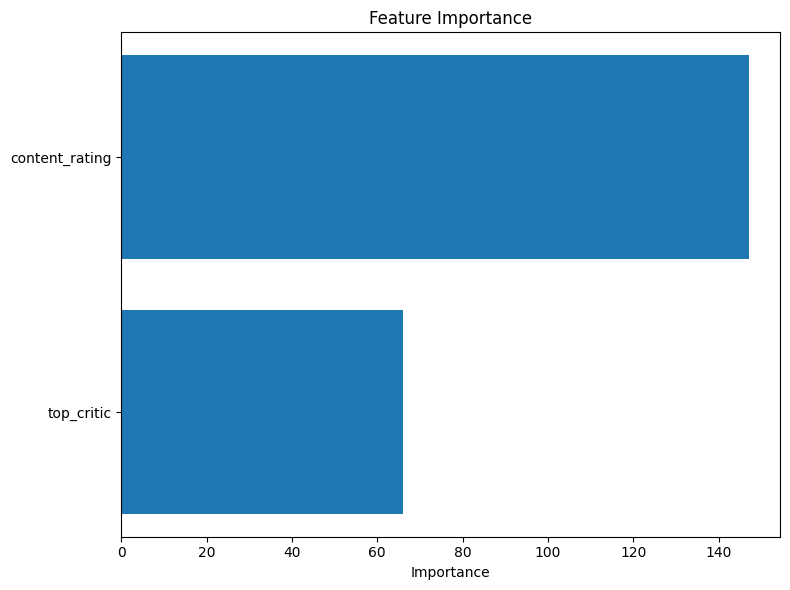

In [42]:
# 特徴量の重要度を横棒グラフで確認
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance["feature"], importance["importance"])
ax.set_xlabel("Importance")
ax.set_title("Feature Importance")
plt.tight_layout()
plt.show()

## 5. 予測ファイル作成

各foldの予測を平均して、最終的な予測値を作成します。

In [43]:
# 5つのfoldの予測を平均
final_pred = np.mean(test_preds, axis=0)

print(f"予測値の統計:")
print(f"  Min: {final_pred.min():.4f}")
print(f"  Max: {final_pred.max():.4f}")
print(f"  Mean: {final_pred.mean():.4f}")

予測値の統計:
  Min: 0.5462
  Max: 0.7372
  Mean: 0.6335


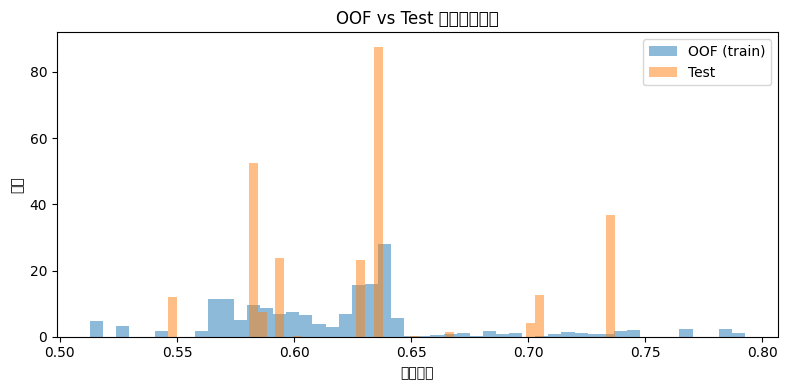

In [44]:
# OOF予測値とtest予測値の分布を比較
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(oof_pred, bins=50, alpha=0.5, label="OOF (train)", density=True)
ax.hist(final_pred, bins=50, alpha=0.5, label="Test", density=True)
ax.set_xlabel("予測確率")
ax.set_ylabel("密度")
ax.set_title("OOF vs Test 予測値の分布")
ax.legend()
plt.tight_layout()
plt.show()

In [45]:
# 提出ファイル作成
submission = pd.DataFrame({
    "ID": test["ID"],
    "target": final_pred
})

print("Submission file preview:")
display(submission.head(10))

Submission file preview:


,ID,target
0,653507,0.629929
1,653508,0.629929
2,653509,0.634583
3,653510,0.634583
4,653511,0.634583
5,653512,0.737189
6,653513,0.737189
7,653514,0.737189
8,653515,0.737189
9,653516,0.737189


In [46]:
# CSVとして保存
submission.to_csv("submission.csv", index=False)
print("Saved: submission.csv")
print(f"  Rows: {len(submission):,}")

Saved: submission.csv
  Rows: 40,716


### 改善のヒント
- CVの分け方について、train-testの関係に近くなるような工夫を行う
- ジャンルごと、役者ごとなどの平均Fresh率を特徴量にする
- movie-infoや、train_text.csvのテキスト情報を活用する